## Visualización
Para analizar este tema, usaremos los datos del número de bicicletas rentadas en Washington para diversos días. El objetivo es predecir cuantas bicicletas en total se rentarán cada día, usando la información temporal (fecha) y de condiciones climáticas de cada día.

Diccionario: http://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset


In [1]:
import pandas as pd
data2 = pd.read_csv('day.csv')

<AxesSubplot:>

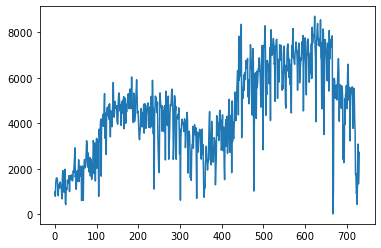

In [2]:
import matplotlib.pyplot as plt
plt.figure
data2['cnt'][:].plot()


In [3]:
data2

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


##### Primero como ejercicio:

Según su conocimiento y el sentido común, ¿Cuáles de estas variables creen que pueden influir más en los préstamos de bicicleta, y cuáles no afectan tanto?

In [4]:
# Sí Muy Importantes


In [5]:
# No muy importantes


Probablemente del ejercicio anterior, según nuestro conocimiento de negocio, mencionamos muchas variables que podían ser importantes para este problema.

Sin embargo, por ahora, para no quedarnos solo con el conocimiento de negocio, usemos visualizaciones que nos ayuden a determinar si las variables que creíamos importantes si lo son realmente o no y que nos sirven como evidencia para sustentar nuestras hipótesis.
 
###### NOTA: En el módulo 4 veremos cómo usar la estadística para corroborar y detectar cuáles son las variables más importantes.


# Visualización: 
## Evidencias visuales para analizar y sustentar la importancia de las variables

Ahora, vamos ver cómo podemos usar evidencias visuales (gráficas) para sustentar el hecho de qué ciertas variables sí sean de importancia o no para nuestro problema.

Así, veremos cuáles evidencias visuales se pueden usar para mostrar convincentemente la importancia de las variables.



#### Evidencias visuales para convencer

Complementando el conocimiento de negocio junto con las técnicas estadísticas, se puede entonces obtener cuales son las variables más importantes para modelar una problemática (las técnicas estadísticas para esto las veremos en otro módulo).

Sin embargo, para poder convencer al público de que dichas variables son importantes, es conveniente acompañar los análisis anteriores de gráficos que sustenten las relaciones que queremos mostrar.

De esta forma, a continuación procederemos a intentar verificar a través del uso de evidencias visuales, si algunas de las variables que tenemos son importantes o no para modelar el número de bicicletas rentadas.

### Temperatura
Podemos plantearnos hipótesis como por ejemplo "En caso de temperaturas bajas, la gente tenderá a usar menos bicicletas", y buscar evidencias visuales o estadísticas para probar nuestro punto y  así determinar que la variable "temperatura" si es influyente. Comprobémoslo gráficamente.

Por ejemplo, miremos la siguiente gráfica:

<AxesSubplot:xlabel='cnt', ylabel='temp'>

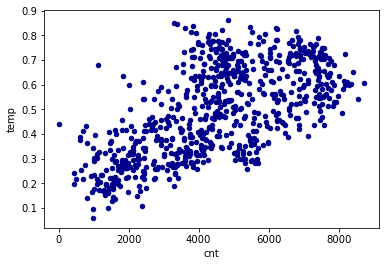

In [6]:
data2.plot.scatter(x='cnt',y='temp',
                       c='DarkBlue')

Se ve que existe una tendencia positiva: mientras más alta es la temperatura, mas bicicletas se usan. Así, se ve claramente que la temperatura si es importante para determinar el número de bicicletas que se prestan.

### Mes del año
También podemos plantearnos por ejemplo la pregunta de si el mes del año influye o no en el numero de bicicletas prestadas.

Veamos si con gráficas podemos detectar esta relación.

<AxesSubplot:title={'center':'Préstamos de bicicleta promedio diario por mes'}, xlabel='Mes', ylabel='Préstamos'>

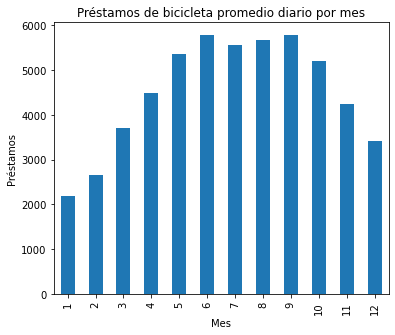

In [7]:

dfg = data2.groupby(['mnth'])['cnt'].mean()

dfg.plot(kind='bar', title='Préstamos de bicicleta promedio diario por mes', ylabel='Préstamos',
         xlabel='Mes', figsize=(6, 5))

Aquí se ve, como era de esperar, que los préstamos promedios diarios en meses de verano (mayo a septiembre) son mucho mayores que en los meses de diciembre y enero, por ejemplo. Por ende, esta variable sí es importante para nuestra problemática.

### Temporada: verano

##### Ahora, un ejemplo de lo que NO se debe hacer.

Suponer que quisieramos ver si el estar en verano influye en que aumente la cantidad de préstamos. Calculemos entonces los préstamos totales para esta estación (0 si no está en verano, y 1 si sí).

Para esto, debemos crear una columna aparte que marque un 1 si correspondía a verano y 0 si no.

In [8]:
# Crear columna para ver si era o no verano
# Recordar que la season = 3 correspondía a verano
# Asi que marcamos con 1 si season era 3, y 0 si no
import numpy as np
data2["verano"] = np.where(data2['season']== 3, 1, 0)
data2.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,verano
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,0
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,0
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,0
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,0
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,0


<AxesSubplot:title={'center':'Préstamos de bicicleta totales'}, ylabel='Verano'>

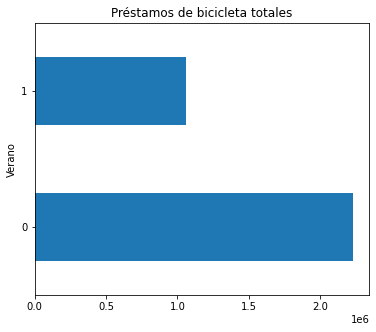

In [9]:
dfg = data2.groupby(['verano'])['cnt'].sum()

dfg.plot(kind='barh', title='Préstamos de bicicleta totales', ylabel='Préstamos',
         xlabel='Verano', figsize=(6, 5))


La gráfica anterior no es adecuada!!!


Puede dar la idea de que en verano se prestan menos bicicletas.

Sin embargo, no es justa la comparación:

No se puede comparar la suma porque hay solo 3 meses de verano y 9 meses de no verano.

Se debe hacer con la media:

<AxesSubplot:title={'center':'Préstamos de bicicleta PROMEDIO diarios'}, ylabel='Verano'>

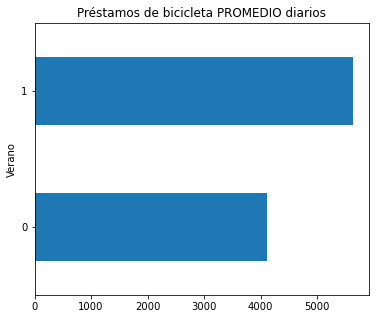

In [10]:

dfg = data2.groupby(['verano'])['cnt'].mean()

dfg.plot(kind='barh', title='Préstamos de bicicleta PROMEDIO diarios', ylabel='Préstamos',
         xlabel='Verano', figsize=(6, 5))

Aquí si se aprecia correctamente que en verano se arriendan más bicicletas en promedio que en las demás estaciones. Por lo que se concluye que la variable de estar en verano si es importante.

### Día de la semana
Por último, intentemos mostrar si el día de la semana influye en los prestamos de bicicletas. (0 es domingo, 6 es sábado).



<AxesSubplot:title={'center':'Préstamos de bicicleta promedio diario por día de la semana'}, xlabel='Día de la semana', ylabel='Préstamos'>

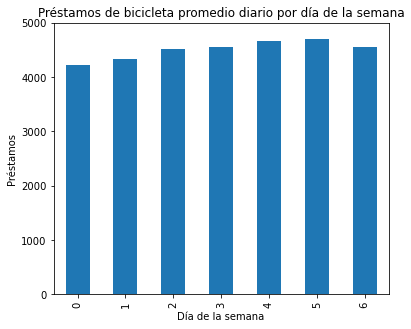

In [11]:
dfg = data2.groupby(['weekday'])['cnt'].mean()

dfg.plot(kind='bar', title='Préstamos de bicicleta promedio diario por día de la semana', ylabel='Préstamos',
         xlabel='Día de la semana', figsize=(6, 5), ylim=(0,5000))

Note que, a pesar de que si se ve una leve diferencia entre los préstamos de bicicleta en días de la semana, esta no es tan relevante. 
##### La conclusión de esa gráfica sería que el día de la semana NO parece influir mucho en los préstamos de bicicletas.

Así, las gráficas anteriores nos sirvieron para dar evidencias visuales de las variables que eran importantes para nuestra problemática (y también para las que no lo eran). 

Tenga en cuenta entonces que es buena práctica usar evidencias visuales similares a las anteriores en sus distintos proyectos para poder sustentar la importancia de las variables.